In [ ]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

# Set the project root directory
PROJECT_ROOT = Path().resolve().parent
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"

print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")
print(f"Number of cases: {len(list(DATA_DIR.iterdir()))}")

In [ ]:
# Load sample case
case_id = "BraTS-GLI-00000-000"
case_dir = DATA_DIR / case_id

# Define paths to modalities and segmentation
modalities = {
    "T1 Native":    case_dir / f"{case_id}-t1n.nii.gz",
    "T1 Contrast":  case_dir / f"{case_id}-t1c.nii.gz",
    "T2 Weighted":  case_dir / f"{case_id}-t2w.nii.gz",
    "T2 FLAIR":     case_dir / f"{case_id}-t2f.nii.gz",
}
seg_path = case_dir / f"{case_id}-seg.nii.gz"

# Load modalities and segmentation
volumes = {name: nib.load(str(path)) for name, path in modalities.items()}
seg = nib.load(str(seg_path))

# Print information about the loaded data
vol = list(volumes.values())[0]
print(f"Shape:        {vol.shape}")
print(f"Voxel size:   {vol.header.get_zooms()}")
print(f"Data type:    {vol.get_fdata().dtype}")
print(f"Seg labels:   {np.unique(seg.get_fdata()).astype(int)}")

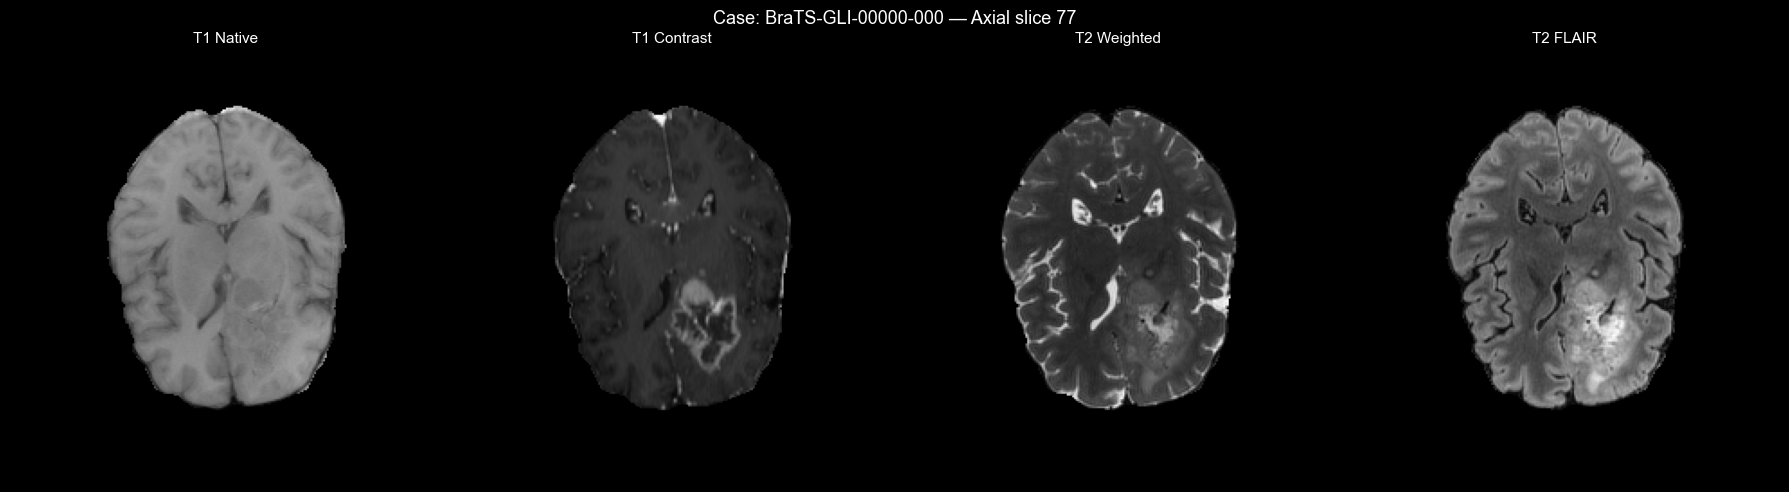

In [28]:
# Get the middle axial slice
mid_idx = vol.shape[2] // 2

# Plot each modality slice side-by-side
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle(f"Case: {case_id} — Axial slice {mid_idx}", fontsize=13)

# Load and plot each modality
for ax, (name, volume) in zip(axes, volumes.items()):
    data = volume.get_fdata()[:, :, mid_idx]
    ax.imshow(data.T, cmap="gray", origin="lower")
    ax.set_title(name, fontsize=11)
    ax.axis("off")

plt.tight_layout()
plt.savefig("../notebooks/figures/modalities.png", dpi=150, bbox_inches="tight")
plt.show()

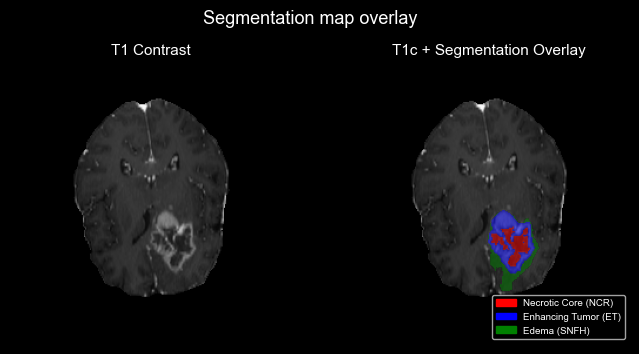

In [29]:
from matplotlib.colors import to_rgba

# Get the middle axial slice of the segmentation map
seg_slice = seg.get_fdata()[:, :, mid_idx].T

# Create a color overlay
overlay = np.zeros((*seg_slice.shape, 4))
color_map = {1:"red", 2:"green", 3:"blue"}

# Overlay the segmentation map with colors
for label, color in color_map.items():
    overlay[seg_slice == label, :] = to_rgba(color, alpha=0.5)

# Create a figure with the segmentation map and overlay
seg_overlay, axis = plt.subplots(1, 2, figsize=(8, 4))
seg_overlay.suptitle("Segmentation map overlay", fontsize=13)

axis[0].imshow(volumes["T1 Contrast"].get_fdata()[:, :, mid_idx].T, cmap="gray", origin="lower")
axis[0].set_title("T1 Contrast", fontsize=11)
axis[0].axis("off")
axis[1].imshow(volumes["T1 Contrast"].get_fdata()[:, :, mid_idx].T, cmap="gray", origin="lower")
axis[1].imshow(overlay, origin="lower")
axis[1].set_title("T1c + Segmentation Overlay", fontsize=11)
axis[1].axis("off")

# Add legend with colors
legend = [
    mpatches.Patch(color="red", label="Necrotic Core (NCR)"),
    mpatches.Patch(color="blue", label="Enhancing Tumor (ET)"),
    mpatches.Patch(color="green", label="Edema (SNFH)")]

plt.legend(handles=legend, loc="lower right", fontsize=7)
plt.savefig("../notebooks/figures/segmap_overlay.png", dpi=150, bbox_inches="tight")
